# Membership Inference Attack

A **membership inference attack** tries to answer the question:

> Was this specific data record part of the model's training set?

This can be a privacy risk. For example:

- in healthcare, membership in a model trained on patients with a rare disease can reveal sensitive medical information;
- in finance, membership in a fraud-detection dataset may reveal sensitive financial history;
- in user modeling, membership may reveal that a person contributed to a sensitive dataset.

The attack exploits the fact that many models behave differently on examples they have seen during training and examples they have not seen. In this notebook, we make that difference visible by creating a small, deliberately overfitted CNN experiment.

## Notation

- members: examples used to train a model;
- non-members: examples from the same distribution, but not used to train that model.
- shadow model: a model whose behavior is *shadowing* the target model
- attack model: a DNN model that predicts whether a data point is member or not

Let's start with the usual import.
We also need evaluation functions:

In [ ]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


Set the seed (reproducibility), the device, and control parameters for the experiments.

In [ ]:
SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

BATCH_SIZE = 64
NUM_CLASSES = 10

# small balanced member/non-member sets.
# A balanced evaluation makes the confusion matrix easier to interpret. Just for experimentation reasons...in real life it can be unbalanced
TARGET_TRAIN_SIZE = 300
SHADOW_TRAIN_SIZE = 300
TARGET_NONMEMBER_SIZE = 300
SHADOW_NONMEMBER_SIZE = 300

# With label noise, the CNN has an incentive to memorize training examples.
LABEL_NOISE_FRACTION = 0.10

# set LR and training epochs for both the target and the shadow model
LEARNING_RATE = 1e-3
TARGET_EPOCHS = 60
SHADOW_EPOCHS = 60

# we also build an attack model
ATTACK_VALIDATION_FRACTION = 0.35
ATTACK_EPOCHS = 300
ATTACK_LEARNING_RATE = 3e-3
ATTACK_WEIGHT_DECAY = 1e-4

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Using device: {DEVICE}")

Using device: cuda


## Dataset configuration

We use MNIST (simple) with the following subsets:

- 300 target training examples and 300 shadow training examples;
- 300 target non-members and 300 shadow non-members (balanced);
- a small % controlled training-label noise for target and shadow members (make the training more interesting since MNIST is too simple);

The label-noise knob is important. It creates memorization pressure: fitting a wrong label cannot be explained by the very easy general MNIST patterns.

## Data split strategy

We need several disjoint pieces of data:

1. **Target model data**
   - target members: examples used to train the target model;
   - target non-members: examples not used to train the target model.

2. **Shadow model data**
   - shadow members: examples used to train the shadow model;
   - shadow non-members: examples not used to train the shadow model.

3. **Attack model data**
   - built from the shadow model's outputs;
   - labels are known because we know which shadow examples were members.

**ASSUMPTION**: the attacker does not know the target model's training set, but they can train their own shadow model and observe how membership affects model outputs.

Members and non-members should come from the **same underlying data distribution**. Otherwise, the attack may simply learn distribution shift rather than membership leakage.

In our case, the used data points are MNIST images.

## MIA: why do we need a shadow model?

In a real membership inference scenario, the attacker usually **does not know** which examples were used to train the target model. That is exactly the secret they want to infer.

So there is an immediate supervised-learning problem:

> we need examples labeled as `member` or `non-member` to build an attack classifier, but we do not have those labels for the target model.

This is why we adopt a shadow model...the attacker creates a second model,the **shadow model**, trained on data drawn from the same distribution as the target model's data. For the shadow model, membership labels are known:

- examples used to train the shadow model are labeled `member = 1`;
- examples held out from shadow training are labeled `member = 0`.

Then the attacker queries the shadow model on both groups and records how the model behaves.
Many metrics can be used. The most common are: loss, confidence, entropy, prediction margin, correctness, and the probability vector. These become the inputs to the attack classifier.

**Transfer assumption**: if the shadow model and target model are trained in similar ways on data from similar (or the same, as in this case) distributions, then member/non-member behavior learned from the shadow model may transfer to the target model.


In [ ]:
# MNIST images are normalized with the usual mean and standard deviation.

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

mnist_train = datasets.MNIST(root="data", train=True, download=True, transform=transform)
mnist_test = datasets.MNIST(root="data", train=False, download=True, transform=transform)

print(f"MNIST train examples: {len(mnist_train):,}")
print(f"MNIST test examples:  {len(mnist_test):,}")

MNIST train examples: 60,000
MNIST test examples:  10,000


In [ ]:
# We create disjoint subsets.
# Target members: examples used to train the target model.
# Shadow members: examples used to train the shadow model.
# Non-members: examples not used to train the corresponding model.
#
# Since we are working with naive MNIST data, we also inject a controlled amount of
# label noise into the training labels of target and shadow members.
# This creates memorization pressure

rng = np.random.default_rng(SEED)
#select random indices for training and testing datasets
train_indices = rng.permutation(len(mnist_train))
test_indices = rng.permutation(len(mnist_test))

#for the target model
target_train_idx = train_indices[:TARGET_TRAIN_SIZE]

#and for the shadow model (controlled by the attaker)
shadow_train_idx = train_indices[TARGET_TRAIN_SIZE:TARGET_TRAIN_SIZE + SHADOW_TRAIN_SIZE]

#let's keep a few non_member data points to
target_nonmember_idx = test_indices[:TARGET_NONMEMBER_SIZE]
shadow_nonmember_idx = test_indices[TARGET_NONMEMBER_SIZE:TARGET_NONMEMBER_SIZE + SHADOW_NONMEMBER_SIZE]


#let's build a function to generate the subsets given the indices above
def materialize_subset(dataset, indices):
    """Return tensors with images and labels for a small subset."""
    images = []
    labels = []
    for index in indices:
        image, label = dataset[int(index)]
        images.append(image)
        labels.append(label)
    return torch.stack(images), torch.tensor(labels, dtype=torch.long)


#for a few samples we also want to make the label "dirty" (i.e., change it)
# just add noise to MNIST dataset because it is too naive and any model will overfit on it
def add_label_noise(clean_labels, fraction, seed):
    """Change a fraction of labels to a wrong class, preserving tensor shape."""
    noisy_labels = clean_labels.clone()
    n_noisy = int(round(fraction * len(noisy_labels)))
    noise_rng = np.random.default_rng(seed)

    if n_noisy == 0:
        return noisy_labels, np.array([], dtype=int)

    noisy_positions = noise_rng.choice(len(noisy_labels), size=n_noisy, replace=False)
    for position in noisy_positions:
        original_label = int(noisy_labels[position])
        candidate_labels = [label for label in range(NUM_CLASSES) if label != original_label]
        noisy_labels[position] = int(noise_rng.choice(candidate_labels))

    return noisy_labels, noisy_positions


target_train_images, target_train_clean_labels = materialize_subset(mnist_train, target_train_idx)
shadow_train_images, shadow_train_clean_labels = materialize_subset(mnist_train, shadow_train_idx)
target_nonmember_images, target_nonmember_labels = materialize_subset(mnist_test, target_nonmember_idx)
shadow_nonmember_images, shadow_nonmember_labels = materialize_subset(mnist_test, shadow_nonmember_idx)

target_train_labels, target_noisy_positions = add_label_noise(
    target_train_clean_labels, LABEL_NOISE_FRACTION, SEED + 1
)
shadow_train_labels, shadow_noisy_positions = add_label_noise(
    shadow_train_clean_labels, LABEL_NOISE_FRACTION, SEED + 2
)

print("Target train examples:", len(target_train_idx))
print("Shadow train examples:", len(shadow_train_idx))
print("Target non-member examples:", len(target_nonmember_idx))
print("Shadow non-member examples:", len(shadow_nonmember_idx))
print(f"Training-label noise: {LABEL_NOISE_FRACTION:.0%}")
print("Noisy target labels:", len(target_noisy_positions))
print("Noisy shadow labels:", len(shadow_noisy_positions))

Target train examples: 300
Shadow train examples: 300
Target non-member examples: 300
Shadow non-member examples: 300
Training-label noise: 10%
Noisy target labels: 30
Noisy shadow labels: 30


In [ ]:
# DataLoaders for training and evaluation.
# The evaluation loaders do not shuffle because we want stable per-example signal tables.
#
# Member loaders use the labels that were used for training. If label noise is
# enabled, the candidate record is therefore the labeled pair (image, training_label).
# This is the record whose membership we are trying to infer.

target_train = TensorDataset(target_train_images, target_train_labels)
shadow_train = TensorDataset(shadow_train_images, shadow_train_labels)
target_nonmember = TensorDataset(target_nonmember_images, target_nonmember_labels)
shadow_nonmember = TensorDataset(shadow_nonmember_images, shadow_nonmember_labels)

target_train_loader = DataLoader(target_train, batch_size=BATCH_SIZE, shuffle=True)
target_train_eval_loader = DataLoader(target_train, batch_size=BATCH_SIZE, shuffle=False)
target_nonmember_loader = DataLoader(target_nonmember, batch_size=BATCH_SIZE, shuffle=False)

shadow_train_loader = DataLoader(shadow_train, batch_size=BATCH_SIZE, shuffle=True)
shadow_train_eval_loader = DataLoader(shadow_train, batch_size=BATCH_SIZE, shuffle=False)
shadow_nonmember_loader = DataLoader(shadow_nonmember, batch_size=BATCH_SIZE, shuffle=False)

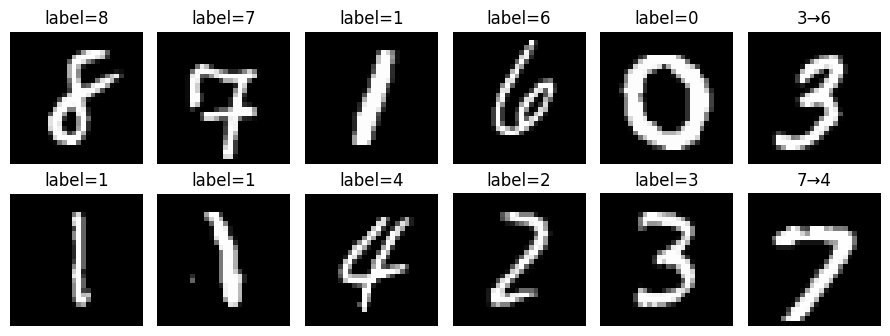

In [ ]:
# let's visualize a few target training examples.
# If label noise is enabled, some titles show clean_label -> training_label.

fig, axes = plt.subplots(2, 6, figsize=(9, 3.5))
for ax, image, clean_label, train_label in zip(
    axes.ravel(),
    target_train_images[:12],
    target_train_clean_labels[:12],
    target_train_labels[:12],
):
    image_for_display = image.squeeze().numpy() * 0.3081 + 0.1307
    ax.imshow(image_for_display, cmap="gray")
    clean_label = int(clean_label)
    train_label = int(train_label)
    if clean_label == train_label:
        ax.set_title(f"label={train_label}")
    else:
        ax.set_title(f"{clean_label}→{train_label}")
    ax.axis("off")
plt.tight_layout()
plt.show()

# DNN Models

We use the same small LeNet-style convolutional neural network for both the target model and the shadow model.

There are three conceptual models in the MIA:

1. **Target model**  
   The victim model. The attacker wants to infer membership in this model's training set.

2. **Shadow model**  
   A model trained by the attacker. Since the attacker controls the shadow model's data, they know which shadow examples are members and non-members.

3. **Attack model**  
   A binary classifier that predicts `member = 1` or `non-member = 0` from the target model's behavior.

In the literature (see reference paper on KIRO), multiple shadow models can be used. Here we use **one shadow model** to keep the runtime low. This is a simplification, but it preserves the key idea: learn the difference between member and non-member behavior from a model whose membership labels are known.

In [ ]:
class SmallLeNetCNN(nn.Module):
    '''A small LeNet-style CNN for 28x28 MNIST images.

    Architecture:
    Conv -> ReLU -> MaxPool -> Conv -> ReLU -> MaxPool -> fully connected layers.
    It is still small enough for Colab Free, but has enough capacity to memorize
    the small training set used in this didactic experiment.
    '''

    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


@torch.no_grad()
def evaluate_accuracy(model, loader):
    '''Compute classification accuracy on one DataLoader.'''
    model.eval()
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        predictions = model(images).argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.numel()

    return correct / total


def train_model(model, train_loader, train_eval_loader, epochs, model_name):
    '''Train a model and return a small history table.'''
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    loss_fn = nn.CrossEntropyLoss()
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        total_seen = 0

        for images, labels in train_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            optimizer.zero_grad()
            logits = model(images)
            loss = loss_fn(logits, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * labels.numel()
            total_seen += labels.numel()

        train_loss = running_loss / total_seen
        train_accuracy = evaluate_accuracy(model, train_eval_loader)
        history.append({"epoch": epoch, "loss": train_loss, "train_accuracy": train_accuracy})

        if epoch == 1 or epoch % 10 == 0 or epoch == epochs:
            print(f"{model_name:>6s} | epoch {epoch:02d}/{epochs} | loss={train_loss:.4f} | train acc={train_accuracy:.3f}")

    return pd.DataFrame(history)

# Train the target model

The target model is the model we pretend to attack.

In a real setting, this might be a model exposed through an API. The attacker would not see its weights or its training set; they would only send inputs and observe outputs.

In this lab, we train the target model ourselves so that we can evaluate the attack honestly:

- target training examples are the **true members**;
- target held-out examples are the **true non-members**.

## Why overfitting and memorization matter

Membership inference is often easier when a model memorizes training examples. A model that has seen a particular record may return:

- lower loss on that record;
- higher confidence in the training label;
- lower entropy in its output distribution;
- a larger gap between the top two predicted classes.

The label-noise setting amplifies this effect. Clean MNIST digits are often easy for both members and non-members, but noisy training labels can help making the problem more intriguing.

In [ ]:
target_model = SmallLeNetCNN().to(DEVICE)
target_history = train_model(
    model=target_model,
    train_loader=target_train_loader,
    train_eval_loader=target_train_eval_loader,
    epochs=TARGET_EPOCHS,
    model_name="target",
)

target | epoch 01/60 | loss=2.2515 | train acc=0.427
target | epoch 10/60 | loss=0.4343 | train acc=0.907
target | epoch 20/60 | loss=0.0262 | train acc=1.000
target | epoch 30/60 | loss=0.0037 | train acc=1.000
target | epoch 40/60 | loss=0.0020 | train acc=1.000
target | epoch 50/60 | loss=0.0012 | train acc=1.000
target | epoch 60/60 | loss=0.0009 | train acc=1.000


In [ ]:
# Check whether the target model is more accurate on members than non-members.
# A gap is a first sign that membership inference may be possible.

target_member_accuracy = evaluate_accuracy(target_model, target_train_eval_loader)
target_nonmember_accuracy = evaluate_accuracy(target_model, target_nonmember_loader)

print(f"Target accuracy on members:     {target_member_accuracy:.3f}")
print(f"Target accuracy on non-members: {target_nonmember_accuracy:.3f}")
print(f"Generalization gap:             {target_member_accuracy - target_nonmember_accuracy:.3f}")

Target accuracy on members:     1.000
Target accuracy on non-members: 0.880
Generalization gap:             0.120


The privacy-relevant behavior of the model is that it has adapted to details of the training records that do not generalize cleanly to unseen data.

# Train the shadow model/s

The shadow model is the attacker's practice model.

The attacker trains it on data drawn from the same distribution as the target model's data. Since the attacker created the shadow training set, they know exactly which examples are:

- shadow members;
- shadow non-members.

The attacker then queries the shadow model on both groups and records the output behavior. This produces a supervised dataset for learning membership inference.

The shadow model does not need to be identical to the target model. It only needs to reproduce useful behavioral patterns, such as:

- lower loss on members;
- higher confidence on members;
- lower entropy on members;
- larger prediction margins on members.

In a full experiment, several shadow models often give more stable attack training data.

## Attack pipeline

The complete attack has four stages.

**Stage 1 — train the target model.**  
This is the victim model. In the lab we train it ourselves only so that we can later check whether the attack was correct.

**Stage 2 — train the shadow model.**  
This is the attacker's practice model. The attacker knows exactly which shadow examples were used for training.

**Stage 3 — learn member/non-member behavior from the shadow model.**  
We query the shadow model on shadow members and shadow non-members. The resulting table is a labeled attack dataset.

**Stage 4 — apply the learned attack to the target model.**  
Now we query the target model, compute the same features, and ask the attack model to predict whether each target example was a member.


In [ ]:
shadow_model = SmallLeNetCNN().to(DEVICE)
shadow_history = train_model(
    model=shadow_model,
    train_loader=shadow_train_loader,
    train_eval_loader=shadow_train_eval_loader,
    epochs=SHADOW_EPOCHS,
    model_name="shadow",
)

shadow | epoch 01/60 | loss=2.2824 | train acc=0.543
shadow | epoch 10/60 | loss=0.4493 | train acc=0.880
shadow | epoch 20/60 | loss=0.0622 | train acc=1.000
shadow | epoch 30/60 | loss=0.0094 | train acc=1.000
shadow | epoch 40/60 | loss=0.0039 | train acc=1.000
shadow | epoch 50/60 | loss=0.0022 | train acc=1.000
shadow | epoch 60/60 | loss=0.0015 | train acc=1.000


In [ ]:
shadow_member_accuracy = evaluate_accuracy(shadow_model, shadow_train_eval_loader)
shadow_nonmember_accuracy = evaluate_accuracy(shadow_model, shadow_nonmember_loader)

print(f"Shadow accuracy on members:     {shadow_member_accuracy:.3f}")
print(f"Shadow accuracy on non-members: {shadow_nonmember_accuracy:.3f}")
print(f"Generalization gap:             {shadow_member_accuracy - shadow_nonmember_accuracy:.3f}")

Shadow accuracy on members:     1.000
Shadow accuracy on non-members: 0.783
Generalization gap:             0.217


The shadow model should show behavior broadly similar to the target model: high accuracy on its own member examples and lower accuracy on held-out examples.

This matters because the attack is trained on the shadow model and then transferred to the target model. If the shadow model memorizes in a similar way to the target model, the learned attack has a clearer pattern to transfer.

In our implementation, we intentionally use the same architecture, training size, label-noise fraction, and training procedure for both models.

# Attack pipeline - STEP 3


The attacker queries a model and computes signals.

Important signals:

- **loss**: members often have lower loss;
- **true-label confidence**: members often receive higher probability on the correct class;
- **entropy**: members often produce more concentrated probability vectors, therefore lower entropy;

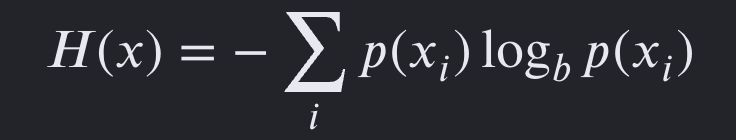

- **margin**: members often have a larger gap between the most likely and second most likely classes;
- **correctness**: members are more likely to be classified correctly when the model overfits.

These are all black-box signals: the attacker only needs the model's output probabilities and the true label of the queried sample.

In [ ]:
#Create a function to extract the membership signals
@torch.no_grad()
def collect_signals(model, loader):
  model.eval()
  loss_fn = nn.CrossEntropyLoss(reduction="none")
  rows = []

  for images, labels in loader:
    images, labels = images.to(DEVICE), labels.to(DEVICE)

    logits = model(images)
    probs = torch.softmax(logits, dim=1)
    loss = loss_fn(logits, labels)

    predicted_labels = probs.argmax(dim=1)
    true_label_conf = probs.gather(1, labels.view(-1, 1)).squeeze(1)

    sorted_probs, _ = probs.sort(dim=1, descending=True)

    margins = sorted_probs[:, 0] - sorted_probs[:, 1]  # probs[everything in the batch, position]

    entropies = -(probs * torch.log(probs + 1e-12)).sum(dim=1)

    correctness = (predicted_labels == labels).float()

    batch = pd.DataFrame({
        "label": labels.cpu().numpy(),
        "predicted_label": predicted_label.cpu().numpy(),
        "loss": loss.cpu().numpy(),
        "true_confidence": true_label_conf.cpu().numpy(),
        "entropy": entropies.cpu().numpy(),
        "margin": margins.cpu().numpy(),
        "correct": correctness.cpu().numpy(),
    })

    probabilities_array = probs.cpu().numpy()

    for class_id in range(NUM_CLASSES):
      batch[f"prob_{class_id}"] = probabilities_array[:, class_id]

    rows.append(batch)

  return pd.concat(rows, ignore_index=True)

In [ ]:
# Collect signals for target and shadow examples.
# These four tables are the raw material for the attacks below.

target_member_signals = collect_signals(target_model, target_train_eval_loader) # just for evalution, not available for the attacker
target_nonmember_signals = collect_signals(target_model, target_nonmember_loader)

shadow_member_signals = collect_signals(shadow_model, shadow_train_eval_loader)
shadow_nonmember_signals = collect_signals(shadow_model, shadow_nonmember_loader)

print("Target member signals:", target_member_signals.shape)
print("Target non-member signals:", target_nonmember_signals.shape)
print("Shadow member signals:", shadow_member_signals.shape)
print("Shadow non-member signals:", shadow_nonmember_signals.shape)

Target member signals: (300, 17)
Target non-member signals: (300, 17)
Shadow member signals: (300, 17)
Shadow non-member signals: (300, 17)


In [ ]:
# NOTE!!!! This part is not avaible to the ATTACKER, we just compute it
# to estimate later the quality of the attack result

target_member_signals["member"] = 1
target_nonmember_signals["member"] = 0
target_signal_table = pd.concat([target_member_signals, target_nonmember_signals], ignore_index=True)

display(
    target_signal_table
    .groupby("member")[["loss", "true_confidence", "entropy", "margin", "correct"]]
    .mean()
    .rename(index={0: "non-member", 1: "member"})
)

,loss,true_confidence,entropy,margin,correct
member,,,,,
non-member,0.516668,0.867516,0.176227,0.873763,0.88
member,0.000853,0.999149,0.006716,0.998512,1.00


# Threshold attack

Before training an attack classifier, we start with the simplest possible attack: a threshold rule.

Examples:

- predict **member** if loss is below a threshold;
- predict **member** if confidence is above a threshold;
- predict **member** if entropy is below a threshold;
- predict **member** if the prediction margin is above a threshold.

## How the threshold is chosen

The attacker chooses the threshold using the shadow model:

1. query the shadow model on shadow members and shadow non-members;
2. search over candidate thresholds;
3. keep the threshold that gives the best balanced accuracy;
4. apply that threshold to the target model.


In [ ]:
#write a function that finds the best thresholds for the different signals

def fit_threshold_attack(member_scores, nonmember_scores, direction):
  '''
  direction =
  1. low_is_member
  2. high_is_member
  '''
  scores = np.concatenate([member_scores, nonmember_scores])
  y_true = np.concatenate([
      np.ones(len(member_scores), dtype=int),
      np.zeros(len(nonmember_scores), dtype=int)
  ])

  thresholds = np.quantile(scores, np.linspace(0.0, 1.0, 201))

  best_threshold = None
  best_balanced_accuracy = 0.0
  best_predictions = None
  for threshold in thresholds:
    if direction == "low_is_member":
      y_pred = (scores <= threshold).astype(int)
      membership_score = -scores

    elif direction == "high_is_member":
      y_pred = (score >= threshold).astype(int)
      membership_score = scores

    else:
      raise ValueError(f"Unknown direction {direction}")

    balanced_accuracy = balanced_accuracy_score(y_true, y_pred)
    if balanced_accuracy > best_balanced_accuracy:
      best_threshold = threshold
      best_balanced_accuracy = balanced_accuracy
      best_predictions = y_pred

  return {
      "threshold": best_threshold,
      "balanced_accuracy": float(best_balanced_accuracy),
      "accuracy": float(accuracy_score(y_true, best_predictions)),
      "auc": float(roc_auc_score(y_true, membership_score)),
  }


In [ ]:
# Fit threshold attacks on the shadow model.
# The attacker can do this because they know shadow membership labels.

threshold_specs = [
    ("loss", "low_is_member"),
    ("entropy", "low_is_member"),
    ("true_confidence", "high_is_member"),
    ("margin", "high_is_member"),
    ("correct", "high_is_member"),
]

threshold_rows = []
for signal_name, direction in threshold_specs:
    fitted = fit_threshold_attack(
        member_scores=shadow_member_signals[signal_name].to_numpy(),
        nonmember_scores=shadow_nonmember_signals[signal_name].to_numpy(),
        direction=direction,
    )
    fitted["signal"] = signal_name
    fitted["direction"] = direction
    threshold_rows.append(fitted)

threshold_results_shadow = pd.DataFrame(threshold_rows).sort_values("balanced_accuracy", ascending=False)
display(threshold_results_shadow)

,threshold,balanced_accuracy,accuracy,auc,signal,direction
0,0.008402,0.711667,0.711667,0.682811,loss,low_is_member
2,0.991633,0.711667,0.711667,0.682811,true_confidence,high_is_member
3,0.986560,0.696667,0.696667,0.672467,margin,high_is_member
1,0.053273,0.691667,0.691667,0.672456,entropy,low_is_member
4,1.000000,0.608333,0.608333,0.608333,correct,high_is_member


In [ ]:
# Evaluate those shadow-chosen thresholds on the target model.
# This is the real test: can thresholds learned from the shadow model transfer to the target?

target_threshold_rows = []
for row in threshold_results_shadow.to_dict("records"):
  #"records" is the orientation argument for Pandas’ to_dict() method.
  #It tells Pandas: Convert the DataFrame into a list of dictionaries,
  #where each row becomes one dictionary.
    signal_name = row["signal"]
    threshold = row["threshold"]
    direction = row["direction"]

    target_scores = np.concatenate([
        target_member_signals[signal_name].to_numpy(),
        target_nonmember_signals[signal_name].to_numpy(),
    ])
    y_true = np.concatenate([
        np.ones(len(target_member_signals), dtype=int),
        np.zeros(len(target_nonmember_signals), dtype=int),
    ])

    if direction == "low_is_member":
        y_pred = (target_scores <= threshold).astype(int)
        membership_score = -target_scores
    else:
        y_pred = (target_scores >= threshold).astype(int)
        membership_score = target_scores

    target_threshold_rows.append({
        "attack": f"threshold on {signal_name}",
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "accuracy": accuracy_score(y_true, y_pred),
        "auc": roc_auc_score(y_true, membership_score), #if auc=0.8 means 80% of y_true=1 (members) has higher membership values
    })

target_threshold_results = pd.DataFrame(target_threshold_rows).sort_values("balanced_accuracy", ascending=False)
display(target_threshold_results)

,attack,balanced_accuracy,accuracy,auc
2,threshold on margin,0.686667,0.686667,0.640967
0,threshold on loss,0.685000,0.685000,0.640272
1,threshold on true_confidence,0.685000,0.685000,0.640272
3,threshold on entropy,0.673333,0.673333,0.640156
4,threshold on correct,0.560000,0.560000,0.560000


# Turn signals into attack features

Threshold attacks use one signal at a time.  
A learned attack can combine several signals.

In the original shadow-model attack, the attack model uses information from the prediction vector and often the true label. Here we use a compact feature set:

- loss;
- true-label confidence;
- entropy;
- margin;
- correctness;
- the full probability vector `prob_0, ..., prob_9`.

This gives the attack classifier both summary statistics and the raw class-probability pattern.

## Feature engineering intuition

The probability vector can reveal more than just whether the prediction was correct. For example:

- the model may be unusually confident on a member;
- the wrong classes may receive a different distribution of probabilities;
- the top-two margin may be larger for members;
- the true class may receive a high score even when another class wins.

The learned attack tries to combine these weak signals.

In [ ]:
#write a function that prepare the features for the attack classifier

def make_attack_features(signal_table):
  prob_columns = [f"prob_{class_id}" for class_id in range(NUM_CLASSES)]

  feature_columns = [
      "loss", "true_confidence","entropy", "correct"] + prob_columns
  return signal_table[feature_columns].copy()

# Train the learned shadow attack

Now we turn membership inference into a standard supervised learning problem.

The shadow model gives us labeled attack data:

- input features: signals extracted from model outputs;
- attack labels: `1 = member`, `0 = non-member`.

In this version, the learned attack is a small **DNN** over tabular attack features. The target and shadow models are CNNs, but the attack input is not an image: it is a vector containing loss, confidence, entropy, margin, correctness, and class probabilities. A compact multilayer perceptron is therefore the natural neural model.

We also tune the final decision threshold on a held-out part of the shadow attack data. This is realistic for the attacker because the attacker knows membership labels for shadow examples.


In [ ]:
#train a binary attack classifier using signal information from the shadow model
#Find an optimal decision threshold and validate on the shadow model

shadow_member_table = shadow_member_signals.copy()
shadow_nonmember_table = shadow_nonmember_signals.copy()
shadow_member_table["member"] = 1
shadow_nonmember_table["member"] = 0

shadow_attack_table = pd.concat([shadow_member_table, shadow_nonmember_table], ignore_index=True)

X_shadow = make_attack_features(shadow_attack_table)
y_shadow = shadow_attack_table["member"].to_numpy()

X_attack_train, X_attack_val, y_attack_train, y_attack_val = train_test_split(
    X_shadow, y_shadow, test_size=ATTACK_VALIDATION_FRACTION, stratify=y_shadow, random_state=SEED)

attack_scaler = StandardScaler().fit(X_attack_train)
X_attack_train_scaled = attack_scaler.transform(X_attack_train)
X_attack_val_scaled = attack_scaler.transform(X_attack_val)

X_attack_train_tensor = torch.tensor(X_attack_train_scaled, dtype=float32).to(DEVICE)
y_attack_train_tensor = torch.tensor(y_attack_train, dtype=float32).to(DEVICE)

X_attack_val_tensor = torch.tensor(X_attack_val_scaled, dtype=float32).to(DEVICE)
# y_attack_val_tensor = torch.tensor(y_attack_val, dtype=float32).to(DEVICE)

class AttackDNN(nn.Module):
  def __init__(self, input_dim):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Linear(input_dim, 32),
        nn.ReLU(),
        nn.Dropout(0.1),
        nn.Linear(32, 16),
        nn.ReLU(),
        nn.Linear(16, 1)
    )

    def forward(self, x):
      return self.layers(x).squeeze(1)

attack_model = AttackDNN(X_attack_train.shape[1]).to(DEVICE)
attack_optimizer = torch.optim.Adam(attack_model.parameters(), lr=ATTACK_LEARNING_RATE, weight_decay=ATTACK_WEIGHT_DECAY)

attack_loss_fn = nn.BCEWithLogitsLoss() # remember that it applies sigmoid internally
attack_loss_history = []

for epoch in range(ATTACK_EPOCHS):
  attack_model.train()
  attack_optimizer.zero_grad()

  logits = attack_model(X_attack_train_tensor)
  loss = attack_loss_fn(logits, y_atack_train_tensor)

  loss.backward()
  attack_optimizer.step()
  attack_loss_history.append(loss.item())

  if epoch % 50 == 0 or epoch == 0:
    print(f"Attack epoch: {epoch}/{ATTACK_EPOCHS}  - loss: {loss.item(): .4f}")

def predict_attack_probability(model, scaler, X):
  X_scaled = scaler.transform(X)
  X_tensor = torch.tensor(X_scaled, dtype=torch.float32).to(DEVICE)
  model.eval()
  with torch.no_grad():
    logits = model(X_tensor)
    probabilities = torch.sigmoid(logits)
    return probabilities.cpu().numpy()

val_membership_probability = predict_attack_probability(attack_model, attack_scaler, X_attack_val)
threshold_search = fit_threshold_attack(
    member_scores=val_membership_probability[y_attack_val == 1],
    nonmember_scores=val_membership_probability[y_attack_val == 0],
    direction="high_is_member",
)

ATTACK_DECISION_THRESHOLD = threshold_search["threshold"]

val_predictions = (val_predictions >= ATTACK_DECISION_THRESHOLD).astype(int)

print("Attack validation results")
print(f"Decision threshold: {ATTACK_DECISION_THRESHOLD:.3f}")
print(f"Accuracy:          {threshold_search['accuracy']:.3f}")
print(f"Balanced accuracy: {threshold_search['balanced_accuracy']:.3f}")
print(f"AUC:               {threshold_search['auc']:.3f}")

Attack epoch 001/300 - loss: 0.6952
Attack epoch 050/300 - loss: 0.5442
Attack epoch 100/300 - loss: 0.5302
Attack epoch 150/300 - loss: 0.5202
Attack epoch 200/300 - loss: 0.5171
Attack epoch 250/300 - loss: 0.5136
Attack epoch 300/300 - loss: 0.5139
Shadow attack validation results
Decision threshold: 0.572
Accuracy:          0.743
Balanced accuracy: 0.743
AUC:               0.772


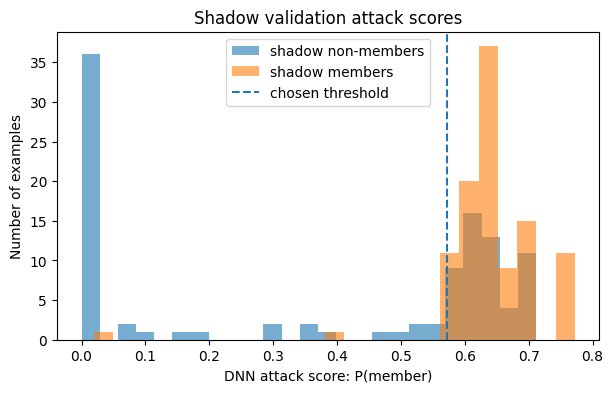

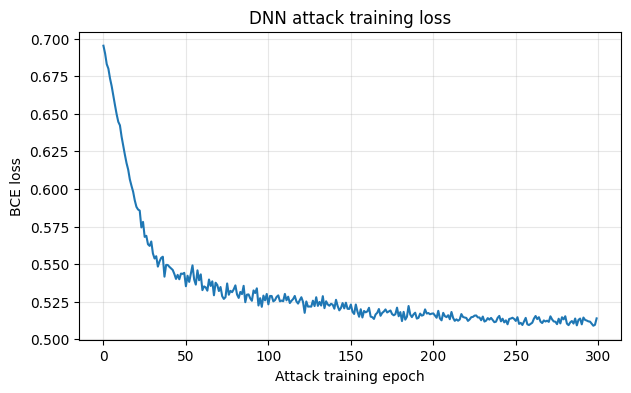

In [ ]:
# Inspect how the learned DNN separates shadow members and non-members.
# A good attack gives higher membership scores to shadow members than to shadow non-members.

plt.figure(figsize=(7, 4))
plt.hist(val_membership_probability[y_attack_val == 0], bins=25, alpha=0.6, label="shadow non-members")
plt.hist(val_membership_probability[y_attack_val == 1], bins=25, alpha=0.6, label="shadow members")
plt.axvline(ATTACK_DECISION_THRESHOLD, linestyle="--", label="chosen threshold")
plt.xlabel("DNN attack score: P(member)")
plt.ylabel("Number of examples")
plt.title("Shadow validation attack scores")
plt.legend()
plt.show()



# Evaluate the learned attack on the target model

This is the actual membership inference evaluation.

The DNN attack model was trained using the shadow model, but it is tested on the target model. We evaluate it on:

1. target members: examples used to train the target model;
2. target non-members: examples not used to train the target model.

The attack is successful if it predicts membership better than random guessing.


In [ ]:
# test the performance of the attack binary classifier on the target model signals
target_member_table = target_member_signals.copy()
target_nonmember_table = target_nonmember_signals.copy()
target_member_table["member"] = 1
target_nonmember_table["member"] = 0

target_attack_table = pd.concat([target_member_table, target_nonmember_table], ignore_index=True)

X_target = make_attack_features(target_attack_table)
y_target = target_attack_table["member"].to_numpy()

target_membership_probability = predict_attack_probability(attack_model, attack_scaler, X_target)
target_predictions = (target_membership_probability >= ATTACK_DECISION_THRESHOLD).astype(int)

learned_attack_result = {
    "attack": "learned DNN shadow attack",
    "balanced_accuracy": balanced_accuracy_score(y_target, target_predictions),
    "accuracy": accuracy_score(y_target, target_predictions),
    "auc": roc_auc_score(y_target, target_membership_probability),
}

print("Learned DNN attack on target model")
print(f"Decision threshold: {ATTACK_DECISION_THRESHOLD:.3f}")
print(f"Accuracy:          {learned_attack_result['accuracy']:.3f}")
print(f"Balanced accuracy: {learned_attack_result['balanced_accuracy']:.3f}")
print(f"AUC:               {learned_attack_result['auc']:.3f}")


Learned DNN attack on target model
Decision threshold: 0.572
Accuracy:          0.670
Balanced accuracy: 0.670
AUC:               0.679


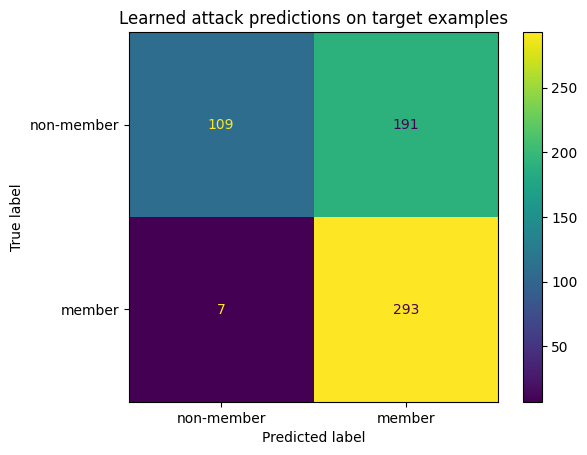

In [ ]:
cm = confusion_matrix(y_target, target_predictions)
ConfusionMatrixDisplay(cm, display_labels=["non-member", "member"]).plot(values_format="d")
plt.title("Learned attack predictions on target examples")
plt.show()

# Confidence rounding as a cheap mitigation

Many deployed APIs do not need to return full-precision probabilities. Reducing the precision of output probabilities can remove some information used by membership attacks.

For example, instead of returning:

```text
[0.00013, 0.00241, 0.98137, ...]
```

an API might return only rounded probabilities:

```text
[0.00, 0.00, 0.98, ...]
```

or even only the predicted label.

## What rounding can and cannot do

Rounding can reduce signals based on fine-grained confidence values, entropy, and margins. However, it is not a full privacy guarantee:

- the predicted label may still leak some information;
- strong overfitting may remain visible even after rounding;
- attackers can adapt to the API format;
